In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


# 数据预处理

In [2]:
# 加载FashionMNIST数据集
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将PIL图像或numpy数组转换为tensor,ToTensor会自动将图像转换为tensor，并归一化到[0,1]范围
    # transforms.Normalize((0.5,), (0.5,))  # 标准化到[-1, 1]范围
])

# 下载并加载训练集
train_dataset = datasets.FashionMNIST(
    root='./data',  # 数据存储路径
    train=True,     # 加载训练集
    download=True,  # 如果数据不存在则下载
    transform=transform
)

# 下载并加载测试集
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,    # 加载测试集
    download=True,
    transform=transform
)

# 打印数据集信息
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"训练集数据类型: {type(train_dataset)}")
print(f"单个dataset元素类型: {type(train_dataset[0])}")
print(f"单个dataset元素是什么: {train_dataset[0]}")
print(f"图像尺寸: {train_dataset[0][0].shape}")
# lables在这个路径https://github.com/zalandoresearch/fashion-mnist
# FashionMNIST类别标签
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")


训练集大小: 60000
测试集大小: 10000
训练集数据类型: <class 'torchvision.datasets.mnist.FashionMNIST'>
单个dataset元素类型: <class 'tuple'>
单个dataset元素是什么: (tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [3]:
print(train_dataset.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
    num_workers=2  # 使用多进程加载数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
    num_workers=2
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
train_iter = iter(train_loader)
batch_images, batch_labels = next(train_iter)
print(f"批次图像张量形状: {batch_images.shape}")
print(f"批次标签张量形状: {batch_labels.shape}")
print(batch_labels)

训练集DataLoader批次数: 1875
测试集DataLoader批次数: 313
每个批次大小: 32
批次图像张量形状: torch.Size([32, 1, 28, 28])
批次标签张量形状: torch.Size([32])
tensor([6, 0, 5, 5, 7, 4, 4, 1, 3, 6, 8, 4, 8, 3, 0, 9, 3, 3, 3, 6, 0, 6, 0, 5,
        7, 2, 8, 5, 6, 3, 3, 2])


In [5]:
28*28

784

在PyTorch中，`DataLoader`是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。`DataLoader`主要负责以下几个方面：

1. **批量加载数据**：`DataLoader`可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。

2. **数据打乱**：默认情况下，`DataLoader`会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。

3. **多线程数据加载**：`DataLoader`支持多线程（通过参数`num_workers`）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。

4. **数据预处理**：`DataLoader`可以与`transforms`结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。

5. **内存管理**：`DataLoader`负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。

6. **易用性**：`DataLoader`提供了一个简单的接口，可以很容易地集成到训练循环中。

# 搭建模型

In [ ]:
import torch
import torch.nn as nn

class SeparableConv(nn.Module):
    """
    深度可分离卷积实现 (depthwise + pointwise)
    即分别执行深度卷积（对每个通道独立卷积）和逐点卷积（1x1卷积混合通道信息），
    以减少模型参数量和计算量，同时保持较强的表达能力。
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        """
        构造函数，初始化深度卷积和逐点卷积两个子层。
        参数说明：
            in_channels : 输入通道数
            out_channels : 输出通道数
            kernel_size : 卷积核大小（如3或(3,3)）
            stride : 步幅，默认1
            padding : 填充，默认0
            bias : 是否添加偏置，默认True
        """
        super(SeparableConv, self).__init__()
        # 深度卷积（Depthwise）：每个输入通道分别用单独的卷积核进行卷积，不混合通道信息
        # groups=in_channels表示每个输入通道独立执行卷积操作
        self.depthwise = nn.Conv2d(
            in_channels,          # 输入通道数
            in_channels,          # 输出通道数（与输入通道数一致）
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=in_channels,   # groups等于输入通道数即是深度卷积
            bias=bias             # 是否有偏置
        )
        # 逐点卷积（Pointwise）：1x1卷积核，用于混合深度卷积输出的各通道特征
        self.pointwise = nn.Conv2d(
            in_channels,          # 输入通道数（来自深度卷积的输出）
            out_channels,         # 输出通道数
            kernel_size=1,        # 1x1卷积，只混合通道，不改变空间尺寸
            stride=1,
            padding=0,
            bias=bias             # 是否有偏置
        )

    def forward(self, x):
        """
        前向传播：
        1. 先经过深度卷积（每个通道独立处理空间特征）
        2. 再经过逐点卷积（1x1卷积，混合不同通道的信息）
        返回值：
            out : 输出张量（shape=(batch_size, out_channels, H, W)）
        """
        out = self.depthwise(x)  # 深度卷积
        out = self.pointwise(out)  # 逐点卷积
        return out


In [7]:
import torch.nn as nn

class FashionCNN(nn.Module):
    def __init__(self, activation=nn.ReLU, **act_kwargs):
        """
        构建用于FashionMNIST分类的卷积神经网络，采用深度可分离卷积。
        参数说明：
        - activation: 激活函数类（如 nn.ReLU、nn.LeakyReLU、nn.SiLU 等），可自定义
        - act_kwargs: 传递给激活函数的附加参数，如 inplace, negative_slope 等
        """
        super().__init__()
        # 第一层 普通卷积层：输入图像通道数为1，输出通道数为32，卷积核为3x3，填充1，保持空间尺寸不变
        # 输出数据形状: (batch, 32, 28, 28)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   

        # 第二层 深度可分离卷积，输入/输出通道数均为32，卷积核为3x3，填充1
        # 输出数据形状: (batch, 32, 28, 28)
        self.conv2 = SeparableConv(32, 32, kernel_size=3, padding=1)  

        # 最大池化层，将空间区域宽高减半： 28x28 -> 14x14
        # 输出数据形状: (batch, 32, 14, 14)
        self.pool = nn.MaxPool2d(2, 2)                           

        # 第三层 深度可分离卷积：输入32通道，输出64通道
        # 输出数据形状: (batch, 64, 14, 14)
        self.conv3 = SeparableConv(32, 64, kernel_size=3, padding=1)  

        # 第四层 深度可分离卷积：输入/输出64通道
        # 输出数据形状: (batch, 64, 14, 14)
        self.conv4 = SeparableConv(64, 64, kernel_size=3, padding=1)  

        # 第五层 深度可分离卷积，输入64通道，输出128通道
        # 输出数据形状: (batch, 128, 7, 7)  (池化后)
        self.conv5 = SeparableConv(64, 128, kernel_size=3, padding=1) 

        # 第六层 深度可分离卷积，输入/输出128通道
        # 输出数据形状: (batch, 128, 7, 7)
        self.conv6 = SeparableConv(128, 128, kernel_size=3, padding=1) 

        # 激活函数（如ReLU、SELU等），传入构造参数，可灵活切换
        self.activation = activation(**act_kwargs)

        # 展平特征为全连接层做准备
        self.flatten = nn.Flatten()

        # 全连接层1，输入为128*3*3（经过三次2x2池化后的空间尺寸），输出128特征
        self.fc1 = nn.Linear(128 * 3 * 3, 128)

        # 全连接层2，最终输出10类（FashionMNIST共10类）
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        """
        前向传播过程，依次经过卷积层、可分离卷积、池化、展平、全连接、激活
        """
        act = self.activation

        # 首卷积+激活
        x = act(self.conv1(x))
        # 深度可分离卷积+激活
        x = act(self.conv2(x))
        # 最大池化，分辨率减半
        x = self.pool(x)

        # 深度可分离卷积3+激活
        x = act(self.conv3(x))
        # 深度可分离卷积4+激活
        x = act(self.conv4(x))
        # 最大池化，分辨率再减半
        x = self.pool(x)

        # 深度可分离卷积5+激活
        x = act(self.conv5(x))
        # 深度可分离卷积6+激活
        x = act(self.conv6(x))
        # 第三次最大池化
        x = self.pool(x)

        # 张量展平，展开为(batch, 128*3*3)
        x = self.flatten(x)
        # 第一个全连接层+激活函数
        x = act(self.fc1(x))
        # 最后一层全连接输出，得到类别分数（未激活，后续用softmax或cross-entropy）
        x = self.fc2(x)
        return x

# 实例化模型，激活函数示例使用SELU。若不指定，则默认ReLU。
model = FashionCNN(activation=nn.SELU)


In [8]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 1, 28, 28)  # batch_size=1, channels=1, height=28, width=28
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [9]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
conv1.weight: 288
conv1.bias: 32
conv2.depthwise.weight: 288
conv2.depthwise.bias: 32
conv2.pointwise.weight: 1024
conv2.pointwise.bias: 32
conv3.depthwise.weight: 288
conv3.depthwise.bias: 32
conv3.pointwise.weight: 2048
conv3.pointwise.bias: 64
conv4.depthwise.weight: 576
conv4.depthwise.bias: 64
conv4.pointwise.weight: 4096
conv4.pointwise.bias: 64
conv5.depthwise.weight: 576
conv5.depthwise.bias: 64
conv5.pointwise.weight: 8192
conv5.pointwise.bias: 128
conv6.depthwise.weight: 1152
conv6.depthwise.bias: 128
conv6.pointwise.weight: 16384
conv6.pointwise.bias: 128
fc1.weight: 147456
fc1.bias: 128
fc2.weight: 1280
fc2.bias: 10
模型总参数量: 184554


In [11]:
32*3*3*64

18432

# 训练

In [10]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)


In [11]:
import wangdao_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


[Step 500] Val Loss: 2.3028 Val Acc: 0.1000
[Step 1000] Val Loss: 2.3014 Val Acc: 0.1000
[Step 1500] Val Loss: 2.2845 Val Acc: 0.1841
Epoch [1/20]  Train Loss: 2.2790  Train Acc: 0.1517
[Step 2000] Val Loss: 1.2704 Val Acc: 0.5555
[Step 2500] Val Loss: 0.9029 Val Acc: 0.6693
[Step 3000] Val Loss: 0.8394 Val Acc: 0.6713
[Step 3500] Val Loss: 0.7552 Val Acc: 0.7273
Epoch [2/20]  Train Loss: 0.8983  Train Acc: 0.6693
[Step 4000] Val Loss: 0.7304 Val Acc: 0.7348
[Step 4500] Val Loss: 0.6763 Val Acc: 0.7489
[Step 5000] Val Loss: 0.6618 Val Acc: 0.7446
[Step 5500] Val Loss: 0.6462 Val Acc: 0.7571
Epoch [3/20]  Train Loss: 0.6602  Train Acc: 0.7491
[Step 6000] Val Loss: 0.6208 Val Acc: 0.7609
[Step 6500] Val Loss: 0.6114 Val Acc: 0.7692
[Step 7000] Val Loss: 0.5854 Val Acc: 0.7792
[Step 7500] Val Loss: 0.5739 Val Acc: 0.7819
Epoch [4/20]  Train Loss: 0.5899  Train Acc: 0.7759
[Step 8000] Val Loss: 0.5676 Val Acc: 0.7847
[Step 8500] Val Loss: 0.5493 Val Acc: 0.7922
[Step 9000] Val Loss: 0.5419

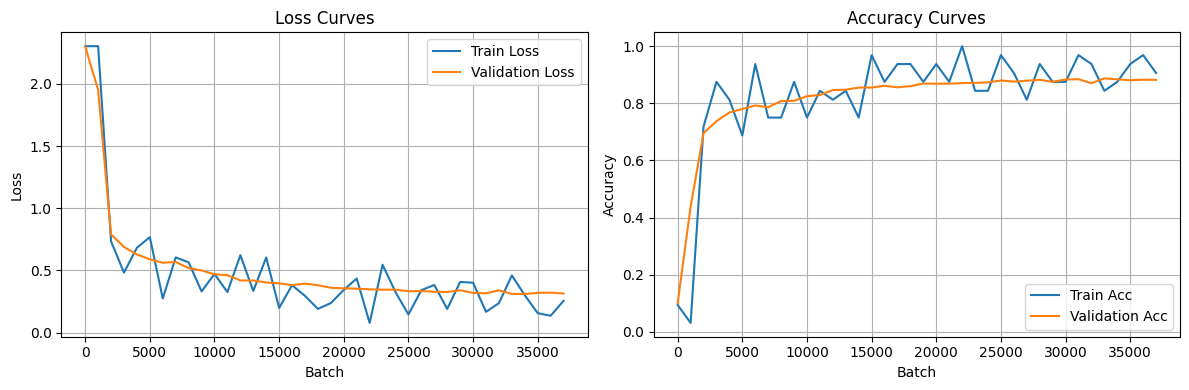

In [14]:
trainer.plot_curves()
